# Create figures relating to time-series filling/drainage data

This notebook generates the following figures:

 - Figure 2
 - Figure 3
 - Figure S5
 - Figure S8


In [1]:

import os, glob, datetime

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import cmcrameri

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

from funcs import add_panel_label, get_aggregate_data, get_gaussian_densities

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 8
plt.rcParams['mathtext.fontset'] = 'cm' 

%matplotlib widget


## Individual Time-series

### Figure 2

Observations for a sample crevasse field in 2019.

In [4]:

crev_field_n = '021'

directory = os.path.join('..', 'data', 'timeseries', 'pondedcrev', crev_field_n)

# Open water
df_water = pd.read_csv(os.path.join(directory, 'timeseries_water.csv'))
df_water['date'] = pd.to_datetime(df_water['date'])

# Open strain
df_strain = pd.read_csv(os.path.join(directory, 'timeseries_strain.csv'))
df_strain['mid_date'] = pd.to_datetime(df_strain['mid_date'], format='ISO8601')
df_strain['date_dt'] = pd.to_timedelta(df_strain['date_dt'])
df_strain['acquisition_date_img1'] = pd.to_datetime(df_strain['acquisition_date_img1'], format='ISO8601')
df_strain['acquisition_date_img2'] = pd.to_datetime(df_strain['acquisition_date_img2'], format='ISO8601')

# Open RACMO
df_racmo = pd.read_csv(os.path.join(directory, 'timeseries_racmo.csv'))
df_racmo['date'] = pd.to_datetime(df_racmo['date'])

# Filter only to water cover with 100% data cover
df_water = df_water[df_water['mask_cover_km2']==0.0]

# Filter only to velcoity cover with 80% data cover
df_strain = df_strain[df_strain['vel_frac_500']>=0.8]


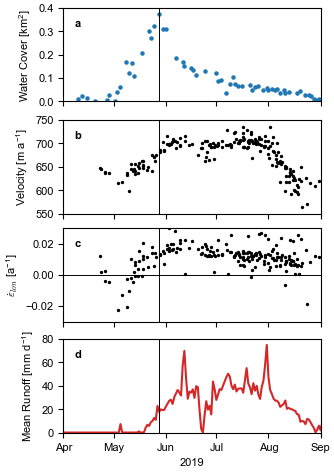

In [3]:
plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(figsize=(85*mm, 120*mm), layout='constrained', nrows=4, sharex=True) # 180 mm wide

ax = axes[0]
df_water[df_water.date.dt.year==2019].plot.scatter('date', 'field_water_cover_km2', ax=ax, s=5)
ax.set_ylabel(r'Water Cover [km$^{\mathdefault{2}}$]')
ax.set_ylim(0, 0.4)
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[1]
df_strain[df_strain.mid_date.dt.year==2019].plot.scatter('mid_date', 'vel_500', ax=ax, s=2, color='k')
ax.set_ylabel(r'Velocity [m a$^{\mathdefault{-1}}$]')
ax.set_ylim(550, 750)
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[2]
df_strain[df_strain.mid_date.dt.year==2019].plot.scatter('mid_date', 'e_lon_500', ax=ax, s=2, color='k')
ax.set_ylabel(r'$\dot{\varepsilon}_{lon}$ [a$^{\mathdefault{-1}}$]')
ax.axhline(0, color='k', lw=.7)
ax.set_ylim(-.03, .03)
add_panel_label(ax, 'c', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[3]
df_racmo[df_racmo.date.dt.year==2019].plot('date', 'mean_runoff_mm_d', ax=ax, color='tab:red', legend=False)
ax.set_ylabel(r'Mean Runoff [mm d$^{\mathdefault{-1}}$]')
# ax.axhline(0, color='k', lw=.7)
ax.set_ylim(0, 80)
add_panel_label(ax, 'd', loc='top left', offset=2*mm, weight='bold', color='k')


ax.set_xlabel('2019')
ax.set_xlim(datetime.datetime(2019,4,1), datetime.datetime(2019,9,1))
for ax in axes.ravel(): 
    ax.minorticks_off()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    ax.axvline(datetime.datetime(2019,5,28), lw=.7, color='k') # Field 28 drains on 2019-05-28
    
plt.savefig('../figures/figure_2.jpg', dpi=600)
plt.savefig('../figures/figure_2.pdf', dpi=300)


### Figure S8

Observations for a sample lake in 2019.

In [6]:

crev_field_n = '040'

directory = os.path.join('..', 'data', 'timeseries', 'lakes', crev_field_n)

# Open water
df_water = pd.read_csv(os.path.join(directory, 'timeseries_water.csv'))
df_water['date'] = pd.to_datetime(df_water['date'])

# Open strain
df_strain = pd.read_csv(os.path.join(directory, 'timeseries_strain.csv'))
df_strain['mid_date'] = pd.to_datetime(df_strain['mid_date'], format='ISO8601')
df_strain['date_dt'] = pd.to_timedelta(df_strain['date_dt'])
df_strain['acquisition_date_img1'] = pd.to_datetime(df_strain['acquisition_date_img1'], format='ISO8601')
df_strain['acquisition_date_img2'] = pd.to_datetime(df_strain['acquisition_date_img2'], format='ISO8601')

# Open RACMO
df_racmo = pd.read_csv(os.path.join(directory, 'timeseries_racmo.csv'))
df_racmo['date'] = pd.to_datetime(df_racmo['date'])

# Filter only to water cover with 100% data cover
df_water = df_water[df_water['mask_cover_km2']==0.0]

# Filter only to velcoity cover with 80% data cover
df_strain = df_strain[df_strain['vel_frac_500']>=0.8]


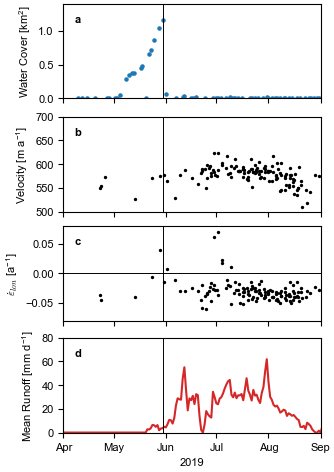

In [ ]:
plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(figsize=(85*mm, 120*mm), layout='constrained', nrows=4, sharex=True) # 180 mm wide

ax = axes[0]
df_water[df_water.date.dt.year==2019].plot.scatter('date', 'field_water_cover_km2', ax=ax, s=5)
ax.set_ylabel(r'Water Cover [km$^{\mathdefault{2}}$]')
ax.set_ylim(0, 1.4)
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[1]
df_strain[df_strain.mid_date.dt.year==2019].plot.scatter('mid_date', 'vel_500', ax=ax, s=2, color='k')
ax.set_ylabel(r'Velocity [m a$^{\mathdefault{-1}}$]')
ax.set_ylim(500, 700)
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[2]
df_strain[df_strain.mid_date.dt.year==2019].plot.scatter('mid_date', 'e_lon_500', ax=ax, s=2, color='k')
ax.set_ylabel(r'$\dot{\varepsilon}_{lon}$ [a$^{\mathdefault{-1}}$]')
ax.axhline(0, color='k', lw=.7)
ax.set_ylim(-.08, .08)
add_panel_label(ax, 'c', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[3]
df_racmo[df_racmo.date.dt.year==2019].plot('date', 'mean_runoff_mm_d', ax=ax, color='tab:red', legend=False)
ax.set_ylabel(r'Mean Runoff [mm d$^{\mathdefault{-1}}$]')
# ax.axhline(0, color='k', lw=.7)
ax.set_ylim(0, 80)
add_panel_label(ax, 'd', loc='top left', offset=2*mm, weight='bold', color='k')


ax.set_xlabel('2019')
ax.set_xlim(datetime.datetime(2019,4,1), datetime.datetime(2019,9,1))
for ax in axes.ravel(): 
    ax.minorticks_off()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    ax.axvline(datetime.datetime(2019,5,30), lw=.7, color='k') # Field 40 drains on 2019-05-30
    
plt.savefig('../figures/figure_S8.jpg', dpi=600)
plt.savefig('../figures/figure_S8.pdf', dpi=300)


## Collated Timeseries

Aggregate all observations

In [2]:

# Vector outlines of crevasse fields and lakes
crevs_ponded = gpd.read_file('../data/outlines/pondedcrevassefields.gpkg')
lakes = gpd.read_file('../data/outlines/lakefields.gpkg')
crevs_empty = gpd.read_file('../data/outlines/emptycrevassefields.gpkg')

# Filter only to fields and lakes that drained in 2019
crevs_ponded = crevs_ponded[(crevs_ponded['valid']==True) & (crevs_ponded['2019_drainage']==True)]
lakes = lakes[(lakes['valid']==True) & (lakes['2019_drainage']==True)]


## Figure 3

e_lon

In [3]:

df_crevs_ponded_strain,  df_crevs_ponded_racmo = get_aggregate_data(crevs_ponded, 'pondedcrev', 2019, relative_to_drainage=True)
df_lakes_strain,  df_lakes_racmo = get_aggregate_data(lakes, 'lakes', 2019, relative_to_drainage=True)
df_crevs_empty_strain, df_crevs_empty_racmo = get_aggregate_data(crevs_empty, 'emptycrev', 2019, relative_to_drainage=False)


40it [00:00, 40.34it/s]
20it [00:00, 44.42it/s]
20it [00:00, 36.51it/s]


In [6]:

x_relative, y_strain, heatmap_ponded_crevs_strain, modes_ponded_crevs_strain = get_gaussian_densities(df_crevs_ponded_strain, 'strain', 'e_lon_500', relative_days=True)
_, _, heatmap_lakes_strain, modes_lakes_strain = get_gaussian_densities(df_lakes_strain, 'strain', 'e_lon_500', relative_days=True)
x_dayofyear, _, heatmap_empty_crevs_strain, modes_empty_crevs_strain = get_gaussian_densities(df_crevs_empty_strain, 'strain', 'e_lon_500', relative_days=False)

_, y_racmo, heatmap_ponded_crevs_racmo, modes_ponded_crevs_racmo = get_gaussian_densities(df_crevs_ponded_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=True)
_, _, heatmap_lakes_racmo, modes_lakes_racmo = get_gaussian_densities(df_lakes_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=True)
_, _, heatmap_empty_crevs_racmo, modes_empty_crevs_racmo = get_gaussian_densities(df_crevs_empty_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=False)



100%|███████████████████████████████████████| 151/151 [00:00<00:00, 4102.82it/s]


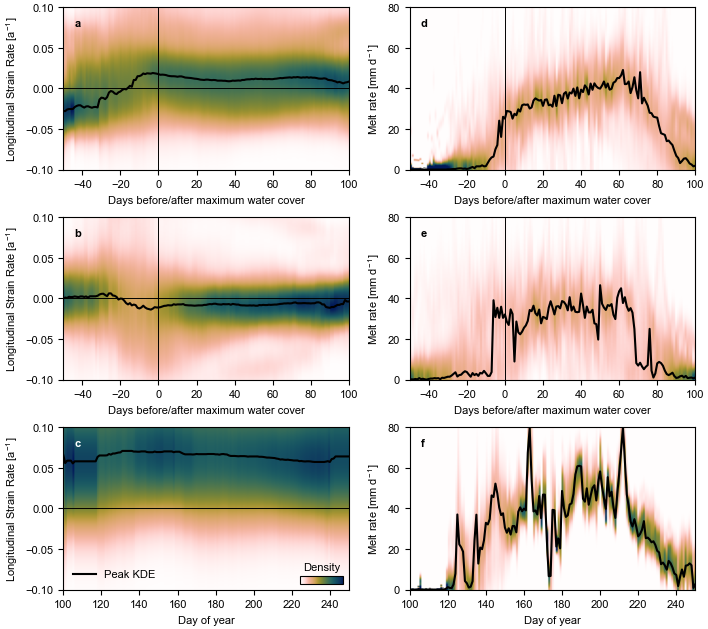

In [30]:

plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(ncols=2, nrows=3, layout='constrained', figsize=(180*mm, 160*mm))

# Ponded crevasse strain rate
ax = axes[0,0]

ax.imshow(
    heatmap_ponded_crevs_strain.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative, modes_ponded_crevs_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Longitudinal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')

# Lakes strain rate
ax = axes[1,0]

ax.imshow(
    heatmap_lakes_strain.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative, modes_lakes_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Longitudinal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')

# Empty crevasse strain rate
ax = axes[2,0]

ax.imshow(
    heatmap_empty_crevs_strain.T, aspect='auto', origin='lower', 
    extent=[x_dayofyear.min(), x_dayofyear.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_dayofyear, modes_empty_crevs_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.set_ylabel(r'Longitudinal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Day of year')
add_panel_label(ax, 'c', loc='top left', offset=2*mm, weight='bold', color='w')

# Legend
line = Line2D([0], [0], color='black', label=r"Peak KDE")
leg = ax.legend(handles=[line], loc="lower left", frameon=False)

# Density colorbar
cmap = mpl.colormaps.get_cmap("cmc.batlowW_r")
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cax = inset_axes(
    ax, width='15%', height='5%', 
    # bbox_to_anchor=(0, 0, 0, 0),
    loc='lower right'
)
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_ticks([])  # remove numbers
cb.set_label("Density")#, labelpad=-35, x=0.5)  
cb.ax.xaxis.set_label_position('top')


# Ponded crevasse melt rate
ax = axes[0,1]

im = ax.imshow(
    heatmap_ponded_crevs_racmo.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_racmo.min(), y_racmo.max()],
    cmap='cmc.batlowW_r', vmin=0, vmax=.1,
)
ax.plot(x_relative, modes_ponded_crevs_racmo, color='k')

ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Melt rate [mm d$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'd', loc='top left', offset=2*mm, weight='bold', color='k')

# Lakes melt rate
ax = axes[1,1]

ax.imshow(
    heatmap_lakes_racmo.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_racmo.min(), y_racmo.max()],
    cmap='cmc.batlowW_r', vmin=0, vmax=.1,
)
ax.plot(x_relative, modes_lakes_racmo, color='k')

ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Melt rate [mm d$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'e', loc='top left', offset=2*mm, weight='bold', color='k')

# Empty crevasse melt rate
ax = axes[2,1]

ax.imshow(
    heatmap_empty_crevs_racmo.T, aspect='auto', origin='lower', 
    extent=[x_dayofyear.min(), x_dayofyear.max(), y_racmo.min(), y_racmo.max()],
    cmap='cmc.batlowW_r', vmin=0, vmax=.1,
)
ax.plot(x_dayofyear, modes_empty_crevs_racmo, color='k')

ax.set_ylabel(r'Melt rate [mm d$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Day of year')
add_panel_label(ax, 'f', loc='top left', offset=2*mm, weight='bold', color='k')

plt.show()
# plt.savefig('../figures/figure_3.png', dpi=300)
plt.savefig('../figures/figure_3.jpg', dpi=600)
plt.savefig('../figures/figure_3.pdf', dpi=600)


### Figure S5

Same, but for e_1 and e_2

In [6]:

df_crevs_ponded_strain,  df_crevs_ponded_racmo = get_aggregate_data(crevs_ponded, 'pondedcrev', 2019, relative_to_drainage=True)
df_lakes_strain,  df_lakes_racmo = get_aggregate_data(lakes, 'lakes', 2019, relative_to_drainage=True)
df_crevs_empty_strain, df_crevs_empty_racmo = get_aggregate_data(crevs_empty, 'emptycrev', 2019, relative_to_drainage=False)


40it [00:00, 43.00it/s]
20it [00:00, 46.24it/s]
20it [00:00, 39.40it/s]


In [9]:

x_relative, y_strain, heatmap_ponded_crevs_strain, modes_ponded_crevs_strain = get_gaussian_densities(df_crevs_ponded_strain, 'strain', 'e_1_500', relative_days=True, vrange=0.15)
_, _, heatmap_lakes_strain, modes_lakes_strain = get_gaussian_densities(df_lakes_strain, 'strain', 'e_1_500', relative_days=True, vrange=0.15)
x_dayofyear, _, heatmap_empty_crevs_strain, modes_empty_crevs_strain = get_gaussian_densities(df_crevs_empty_strain, 'strain', 'e_1_500', relative_days=False, vrange=0.15)

x_relative_2, y_strain_2, heatmap_ponded_crevs_strain_2, modes_ponded_crevs_strain_2 = get_gaussian_densities(df_crevs_ponded_strain, 'strain', 'e_2_500', relative_days=True, vrange=0.15)
_, _, heatmap_lakes_strain_2, modes_lakes_strain_2 = get_gaussian_densities(df_lakes_strain, 'strain', 'e_2_500', relative_days=True, vrange=0.15)
x_dayofyear_2, _, heatmap_empty_crevs_strain_2, modes_empty_crevs_strain_2 = get_gaussian_densities(df_crevs_empty_strain, 'strain', 'e_2_500', relative_days=False, vrange=0.15)


# _, y_racmo, heatmap_ponded_crevs_racmo, modes_ponded_crevs_racmo = get_gaussian_densities(df_crevs_ponded_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=True)
# _, _, heatmap_lakes_racmo, modes_lakes_racmo = get_gaussian_densities(df_lakes_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=True)
# _, _, heatmap_empty_crevs_racmo, modes_empty_crevs_racmo = get_gaussian_densities(df_crevs_empty_racmo, 'racmo', 'mean_runoff_mm_d', relative_days=False)



100%|████████████████████████████████████████| 151/151 [00:00<00:00, 492.36it/s]


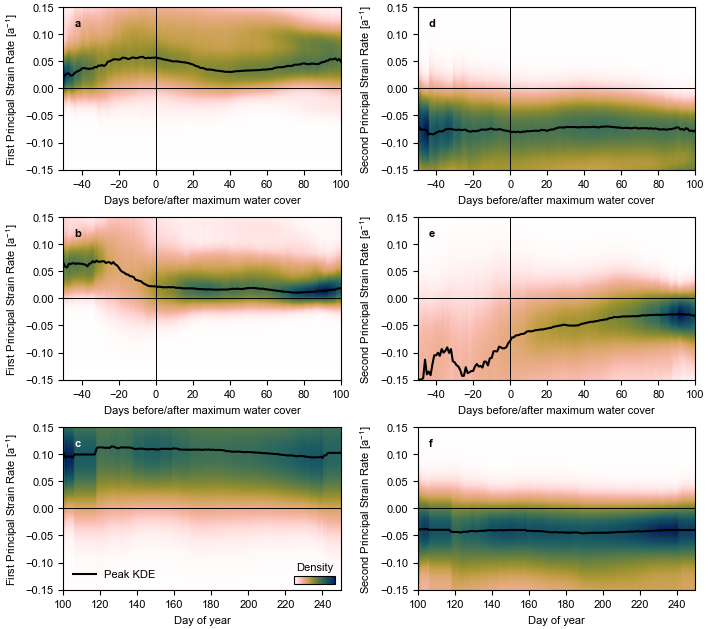

In [11]:

plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(ncols=2, nrows=3, layout='constrained', figsize=(180*mm, 160*mm))

# Ponded crevasse strain rate
ax = axes[0,0]

ax.imshow(
    heatmap_ponded_crevs_strain.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative, modes_ponded_crevs_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'First Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')

# Lakes strain rate
ax = axes[1,0]

ax.imshow(
    heatmap_lakes_strain.T, aspect='auto', origin='lower', 
    extent=[x_relative.min(), x_relative.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative, modes_lakes_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'First Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')

# Empty crevasse strain rate
ax = axes[2,0]

ax.imshow(
    heatmap_empty_crevs_strain.T, aspect='auto', origin='lower', 
    extent=[x_dayofyear.min(), x_dayofyear.max(), y_strain.min(), y_strain.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_dayofyear, modes_empty_crevs_strain, color='k')

ax.axhline(0, c='k', lw=.7)
ax.set_ylabel(r'First Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Day of year')
add_panel_label(ax, 'c', loc='top left', offset=2*mm, weight='bold', color='w')

# Legend
line = Line2D([0], [0], color='black', label=r"Peak KDE")
leg = ax.legend(handles=[line], loc="lower left", frameon=False)

# Density colorbar
cmap = mpl.colormaps.get_cmap("cmc.batlowW_r")
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cax = inset_axes(
    ax, width='15%', height='5%', 
    # bbox_to_anchor=(0, 0, 0, 0),
    loc='lower right'
)
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_ticks([])  # remove numbers
cb.set_label("Density")#, labelpad=-35, x=0.5)  
cb.ax.xaxis.set_label_position('top')



# Ponded crevasse strain rate
ax = axes[0,1]

ax.imshow(
    heatmap_ponded_crevs_strain_2.T, aspect='auto', origin='lower', 
    extent=[x_relative_2.min(), x_relative_2.max(), y_strain_2.min(), y_strain_2.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative_2, modes_ponded_crevs_strain_2, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Second Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'd', loc='top left', offset=2*mm, weight='bold', color='k')

# Lakes strain rate
ax = axes[1,1]

ax.imshow(
    heatmap_lakes_strain_2.T, aspect='auto', origin='lower', 
    extent=[x_relative_2.min(), x_relative_2.max(), y_strain_2.min(), y_strain_2.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_relative_2, modes_lakes_strain_2, color='k')

ax.axhline(0, c='k', lw=.7)
ax.axvline(0, c='k', lw=.7)
ax.set_ylabel(r'Second Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Days before/after maximum water cover')
add_panel_label(ax, 'e', loc='top left', offset=2*mm, weight='bold', color='k')

# Empty crevasse strain rate
ax = axes[2,1]

ax.imshow(
    heatmap_empty_crevs_strain_2.T, aspect='auto', origin='lower', 
    extent=[x_dayofyear_2.min(), x_dayofyear_2.max(), y_strain_2.min(), y_strain_2.max()],
    cmap='cmc.batlowW_r', vmin=0,
)
ax.plot(x_dayofyear_2, modes_empty_crevs_strain_2, color='k')

ax.axhline(0, c='k', lw=.7)
ax.set_ylabel(r'Second Principal Strain Rate [a$^{\mathdefault{-1}}$]')
ax.set_xlabel(r'Day of year')
add_panel_label(ax, 'f', loc='top left', offset=2*mm, weight='bold', color='k')


plt.show()
# plt.savefig('../figures/figure_S5.png', dpi=300)
plt.savefig('../figures/figure_S5.jpg', dpi=600)
plt.savefig('../figures/figure_S5.pdf', dpi=600)
